# Balanced Dataset Training

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import shutil
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import multiprocessing

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB2
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

2026-03-04 18:57:18.110970: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 18:57:19.196908: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 18:57:34.213201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORGANIZED_DIR = DATA_DIR / "organized"
GENERATED_DIR = DATA_DIR / "generated"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

IMG_SIZE = 256
BATCH_SIZE = 64
NUM_CLASSES = 8
CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

## 1. Build Balanced Training Directory
We combine real training images with CGAN-generated synthetic images to create a balanced dataset. Only minority classes receive synthetic augmentation — the majority class (NV) is left as-is.

In [3]:
BALANCED_TRAIN_DIR = DATA_DIR / "organized_balanced" / "train"
real_train_dir = ORGANIZED_DIR / "train"

In [4]:
def copy_file(src, dst):
    try:
        dst.parent.mkdir(parents=True, exist_ok=True)
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
            return 1
    except Exception:
        pass
    return 0

In [5]:
def copy_real_images(real_train_dir, balanced_dir, class_names):

    tasks = []

    for cls_name in class_names:
        src_dir = real_train_dir / cls_name
        dst_dir = balanced_dir / cls_name

        for img_file in src_dir.glob("*.jpg"):
            dst = dst_dir / img_file.name
            tasks.append((img_file, dst))

    copied = 0
    workers = min(16, multiprocessing.cpu_count())

    with ThreadPoolExecutor(max_workers=workers) as executor:
        futures = [executor.submit(copy_file, src, dst) for src, dst in tasks]

        for f in tqdm(as_completed(futures), total=len(futures), desc="Copying real images"):
            copied += f.result()

    return copied

In [6]:
def copy_synthetic_images(generated_dir, balanced_dir, class_names):

    tasks = []
    stats = {}

    for cls_name in class_names:
        syn_dir = generated_dir / cls_name

        if not syn_dir.exists():
            continue

        dst_dir = balanced_dir / cls_name
        syn_files = list(syn_dir.glob("*.jpg"))

        stats[cls_name] = len(syn_files)

        for img_file in syn_files:
            dst = dst_dir / img_file.name
            tasks.append((img_file, dst))

    copied = 0
    workers = min(16, multiprocessing.cpu_count())

    with ThreadPoolExecutor(max_workers=workers) as executor:
        futures = [executor.submit(copy_file, src, dst) for src, dst in tasks]

        for f in tqdm(as_completed(futures), total=len(futures), desc="Copying synthetic images"):
            copied += f.result()

    return copied, stats

In [7]:
# copy real images
real_count = copy_real_images(real_train_dir, BALANCED_TRAIN_DIR, CLASS_NAMES)
print(f"Real training images copied: {real_count}")

# copy synthetic images
syn_count, syn_stats = copy_synthetic_images(GENERATED_DIR, BALANCED_TRAIN_DIR, CLASS_NAMES)

for cls, n in syn_stats.items():
    print(f"{cls}: +{n} synthetic images")

print("Balanced training directory ready.")

Copying real images: 100%|██████████| 7010/7010 [00:14<00:00, 478.89it/s]


Real training images copied: 7010


Copying synthetic images: 100%|██████████| 25841/25841 [00:51<00:00, 498.32it/s]

AKIEC: +4464 synthetic images
BCC: +4333 synthetic images
BKL: +3924 synthetic images
DF: +4612 synthetic images
MEL: +3914 synthetic images
VASC: +4594 synthetic images
Balanced training directory ready.


In [10]:
# Print class counts after balancing
print("Class counts in balanced training set:")
for cls_name in CLASS_NAMES:
    cls_dir = BALANCED_TRAIN_DIR / cls_name
    if cls_dir.exists():
        n = len(list(cls_dir.glob("*.jpg")))
        print(f"  {cls_name}: {n}")

Class counts in balanced training set:
  AKIEC: 4693
  BCC: 4693
  BKL: 4693
  DF: 4693
  MEL: 4693
  NV: 4693
  VASC: 4693


## 2. Load Balanced Dataset

In [11]:
balanced_train_ds = keras.utils.image_dataset_from_directory(
    BALANCED_TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

# Val and test remain unchanged (real images only)
val_ds = keras.utils.image_dataset_from_directory(
    ORGANIZED_DIR / "val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    ORGANIZED_DIR / "test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
balanced_train_ds = balanced_train_ds.prefetch(AUTOTUNE)
val_ds  = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print(f"Balanced train batches: {len(balanced_train_ds)}")

Found 32851 files belonging to 7 classes.


I0000 00:00:1772650732.294131  537564 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1502 files belonging to 7 classes.
Found 1503 files belonging to 7 classes.
Balanced train batches: 514


## 3. Build and Train Model on Balanced Data

In [12]:
def build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    img_aug = keras.Sequential([
        layers.RandomRotation(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomFlip(),
        layers.RandomContrast(0.1),
    ], name="aug")

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = img_aug(inputs)
    base = EfficientNetB2(include_top=False, weights="imagenet", input_tensor=x)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs), base

In [13]:
model_balanced, base_balanced = build_model()

model_balanced.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

save_dir = MODELS_DIR / "balanced_cgan"
save_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(str(save_dir / 'phase1.keras'), monitor='val_accuracy', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

print("Phase 1: Feature extraction on balanced dataset")
hist_1 = model_balanced.fit(
    balanced_train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks
)

Phase 1: Feature extraction on balanced dataset
Epoch 1/20


2026-03-04 18:59:06.684668: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


514/514 ━━━━━━━━━━━━━━━━━━━━ 118s 206ms/step - accuracy: 0.2771 - loss: 1.7875 - val_accuracy: 0.7064 - val_loss: 0.8788 - learning_rate: 0.0100
Epoch 2/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 102s 199ms/step - accuracy: 0.2777 - loss: 1.7860 - val_accuracy: 0.6478 - val_loss: 1.0074 - learning_rate: 0.0100
Epoch 3/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 103s 199ms/step - accuracy: 0.2852 - loss: 1.8012 - val_accuracy: 0.6991 - val_loss: 1.1156 - learning_rate: 0.0100
Epoch 4/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 103s 200ms/step - accuracy: 0.2826 - loss: 1.7873 - val_accuracy: 0.6951 - val_loss: 0.9222 - learning_rate: 0.0100
Epoch 5/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 104s 202ms/step - accuracy: 0.2809 - loss: 1.7714 - val_accuracy: 0.7097 - val_loss: 0.9618 - learning_rate: 0.0100
Epoch 6/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 102s 199ms/step - accuracy: 0.2794 - loss: 1.8059 - val_accuracy: 0.7037 - val_loss: 0.8653 - learning_rate: 0.0100
Epoch 7/20
514/514 ━━━━━━━━━━━━━━━━━━━━ 102s 199ms/step - accuracy: 0.2807 

In [14]:
# base_balanced.trainable = True
model_balanced.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks[1] = keras.callbacks.ModelCheckpoint(
    str(save_dir / 'final.keras'), monitor='val_accuracy', save_best_only=True
)

print("Phase 2: Fine-tuning on balanced dataset")
hist_2 = model_balanced.fit(
    balanced_train_ds, validation_data=val_ds, epochs=30,
    callbacks=callbacks, initial_epoch=len(hist_1.history['loss'])
)

Phase 2: Fine-tuning on balanced dataset
Epoch 21/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 113s 206ms/step - accuracy: 0.2904 - loss: 1.5960 - val_accuracy: 0.7244 - val_loss: 0.7535 - learning_rate: 1.0000e-04
Epoch 22/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 103s 200ms/step - accuracy: 0.2960 - loss: 1.5891 - val_accuracy: 0.7217 - val_loss: 0.7478 - learning_rate: 1.0000e-04
Epoch 23/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 103s 200ms/step - accuracy: 0.2912 - loss: 1.5890 - val_accuracy: 0.7250 - val_loss: 0.7488 - learning_rate: 1.0000e-04
Epoch 24/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 102s 199ms/step - accuracy: 0.2939 - loss: 1.5908 - val_accuracy: 0.7230 - val_loss: 0.7471 - learning_rate: 1.0000e-04
Epoch 25/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 103s 200ms/step - accuracy: 0.2902 - loss: 1.5908 - val_accuracy: 0.7250 - val_loss: 0.7437 - learning_rate: 1.0000e-04
Epoch 26/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 103s 199ms/step - accuracy: 0.2933 - loss: 1.5889 - val_accuracy: 0.7244 - val_loss: 0.7400 - learning_rate: 1.00

## 4. Evaluate Balanced Model

In [15]:
y_true_bal, y_pred_bal = [], []
for imgs, labels in test_ds:
    preds = model_balanced.predict(imgs, verbose=0)
    y_pred_bal.extend(np.argmax(preds, axis=1))
    y_true_bal.extend(labels.numpy())

y_true_bal, y_pred_bal = np.array(y_true_bal), np.array(y_pred_bal)
print("Balanced (CGAN) + Unsegmented:")
print(classification_report(y_true_bal, y_pred_bal, target_names=CLASS_NAMES))

Balanced (CGAN) + Unsegmented:
              precision    recall  f1-score   support

       AKIEC       0.43      0.12      0.19        49
         BCC       0.56      0.18      0.27        77
         BKL       0.47      0.35      0.40       165
          DF       0.10      0.12      0.11        17
         MEL       0.36      0.31      0.33       167
          NV       0.81      0.94      0.87      1006
        VASC       0.67      0.27      0.39        22

    accuracy                           0.72      1503
   macro avg       0.49      0.33      0.37      1503
weighted avg       0.69      0.72      0.69      1503



2026-03-04 19:50:58.517368: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5. Full Comparison Across All Variants
Load previously saved per-class results and combine into one comparison table.

In [16]:
def load_json_safe(path):
    if Path(path).exists():
        with open(path) as f:
            return json.load(f)
    return None

baseline    = load_json_safe(RESULTS_DIR / "baseline_summary.json")
weighted    = load_json_safe(RESULTS_DIR / "classweighted_summary.json")
smote       = load_json_safe(RESULTS_DIR / "smote_summary.json")
seg_cls     = load_json_safe(RESULTS_DIR / "segmented_classification_summary.json")

In [17]:
def safe_acc_f1(summary, acc_key='test_accuracy', f1_key='macro_f1'):
    if summary is None:
        return None, None
    acc = summary.get(acc_key)
    f1  = summary.get(f1_key)
    if acc is None:
        # baseline/weighted use per_class_accuracy + class_totals
        correct = sum(summary.get('class_correct', {}).values())
        total   = sum(summary.get('class_totals', {}).values())
        acc = correct / total if total > 0 else None
    return acc, f1

rows = [
    {"Variant": "1. Unbalanced + Unsegmented",         **dict(zip(["Accuracy", "Macro_F1"], safe_acc_f1(baseline)))},
    {"Variant": "2. Weighted + Unsegmented",           **dict(zip(["Accuracy", "Macro_F1"], safe_acc_f1(weighted)))},
    {"Variant": "3. SMOTE + Unsegmented",              **dict(zip(["Accuracy", "Macro_F1"], safe_acc_f1(smote)))},
    {"Variant": "4. Balanced (CGAN) + Unsegmented",
     "Accuracy": float(accuracy_score(y_true_bal, y_pred_bal)),
     "Macro_F1": float(f1_score(y_true_bal, y_pred_bal, average='macro'))},
    {"Variant": "5. Unbalanced + Segmented",
     "Accuracy": seg_cls.get('variant_a_accuracy') if seg_cls else None,
     "Macro_F1": seg_cls.get('variant_a_macro_f1') if seg_cls else None},
    {"Variant": "6. Weighted + Segmented",
     "Accuracy": seg_cls.get('variant_b_accuracy') if seg_cls else None,
     "Macro_F1": seg_cls.get('variant_b_macro_f1') if seg_cls else None},
]

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

                         Variant  Accuracy  Macro_F1
     1. Unbalanced + Unsegmented  0.735196       NaN
       2. Weighted + Unsegmented  0.620758       NaN
          3. SMOTE + Unsegmented  0.776447  0.566129
4. Balanced (CGAN) + Unsegmented  0.722555  0.366189
       5. Unbalanced + Segmented  0.700599  0.365166
         6. Weighted + Segmented  0.572854  0.366369


## 6. Visualization

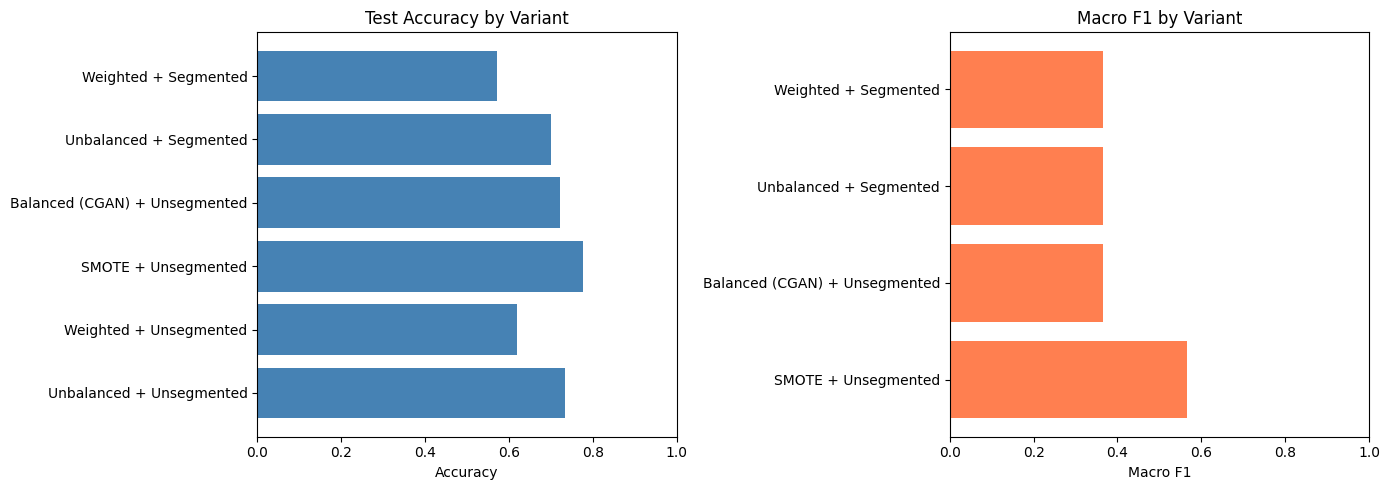

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = comparison_df.dropna(subset=["Accuracy"])

x = range(len(valid))
labels = [v.split('. ', 1)[1] for v in valid['Variant']]

axes[0].barh(labels, valid['Accuracy'], color='steelblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Test Accuracy by Variant')
axes[0].set_xlim(0, 1)

valid_f1 = comparison_df.dropna(subset=["Macro_F1"])
labels_f1 = [v.split('. ', 1)[1] for v in valid_f1['Variant']]
axes[1].barh(labels_f1, valid_f1['Macro_F1'], color='coral')
axes[1].set_xlabel('Macro F1')
axes[1].set_title('Macro F1 by Variant')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

This comparison quantifies the combined effect of balancing strategy (none / class weights / SMOTE / CGAN) and segmentation on final classification performance. The best performer from this table goes into hyperparameter tuning (Notebook 17).

In [19]:
comparison_df.to_csv(RESULTS_DIR / "full_model_comparison.csv", index=False)

# Identify best variant
best_row = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"Best variant: {best_row['Variant']}")
print(f"  Accuracy: {best_row['Accuracy']:.4f}")
print(f"  Macro F1: {best_row['Macro_F1']}")

with open(RESULTS_DIR / "best_variant.json", "w") as f:
    json.dump({
        "best_variant": best_row['Variant'],
        "accuracy": float(best_row['Accuracy']) if best_row['Accuracy'] is not None else None,
        "macro_f1": float(best_row['Macro_F1']) if best_row['Macro_F1'] is not None else None
    }, f, indent=2)

print("Comparison results saved.")

Best variant: 3. SMOTE + Unsegmented
  Accuracy: 0.7764
  Macro F1: 0.5661288159858682
Comparison results saved.
